In [408]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
pd.options.mode.chained_assignment = None
TRAINING_SIZE = 400
TESTING_SIZE = 100



data = pd.read_csv('swiss_job_offers.csv')

data = data.drop('MaternityLeaveWeeks', axis=1)
data = data.drop('PaternityLeaveWeeks', axis=1)
data = data.drop('CitySize', axis=1)
data = data.drop('Perks', axis=1)
data['Languages'] = data['Languages'].fillna('unknown')

#data[data.isna().any(axis=1)]
data

,Diploma,MinYearsExperience,Role,Contract,Industry,Canton,CompanySize,Languages,Holidays,WorkloadPercent,SalaryCHF
0,PhD,7 to 20,Manager,Permanent,Education,ZH,Small (50-200),"English, German",25,100,314500
1,Bachelor,4 to 10,Senior,Permanent,Manufacturing,SO,Large (1000+),"French, German",25,100,143600
2,Bachelor,2 to 6,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),"English, German",25,100,84300
3,Bachelor,0 to 2,Junior,1 year,Healthcare,BE,Small (50-200),"English, German",25,90,45300
4,PhD,2 to 6,Mid-level,Permanent,Finance,FR,Medium (200-1000),"French, German",26,90,130200
...,...,...,...,...,...,...,...,...,...,...,...
495,Master,0 to 0,Intern,6 months,Hospitality,SO,Startup (<50),"French, English, German",28,60,25000
496,Apprenticeship,0 to 2,Junior,Permanent,Finance,ZH,Medium (200-1000),"French, German",25,80,67600
497,Bachelor,4 to 10,Senior,Permanent,Manufacturing,TG,Large (1000+),German,24,80,122200
498,Bachelor,2 to 6,Mid-level,2 years,Consulting,ZH,Medium (200-1000),German,28,90,103000


In [409]:
data['Diploma'].value_counts()
data['Role'].value_counts()
data['MinYearsExperience'].value_counts()

MinYearsExperience
2 to 6      172
0 to 2      134
4 to 10      94
0 to 0       46
7 to 20      26
6 to 15      26
10 to 30      2
Name: count, dtype: int64

In [410]:
#PUT ALL THE SALARY AT A 100% WORKLOAD
data["SalaryCHF"] = (data["SalaryCHF"] / data["WorkloadPercent"] * 100).round()

data = data.drop('WorkloadPercent', axis=1)

In [411]:
bounds = data["MinYearsExperience"].str.extract(r"(\d+)\s*to\s*(\d+)").astype(float)
data["ExpMin"] = bounds[0]
data["ExpMax"] = bounds[1]
data["ExpMid"] = (bounds[0] + bounds[1]) / 2
data = data.drop(columns="MinYearsExperience")

data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Languages,Holidays,SalaryCHF,ExpMin,ExpMax,ExpMid
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),"English, German",25,314500.0,7.0,20.0,13.5
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),"French, German",25,143600.0,4.0,10.0,7.0
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),"English, German",25,84300.0,2.0,6.0,4.0
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),"English, German",25,50333.0,0.0,2.0,1.0
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),"French, German",26,144667.0,2.0,6.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),"French, English, German",28,41667.0,0.0,0.0,0.0
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),"French, German",25,84500.0,0.0,2.0,1.0
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),German,24,152750.0,4.0,10.0,7.0
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),German,28,114444.0,2.0,6.0,4.0


In [412]:
LANGUAGES = ["French", "German", "English", "Italian"]
for lang in LANGUAGES:
    data[f"Lang_{lang}"] = data["Languages"].str.contains(lang).astype(int)
data["LangCount"] = data[[f"Lang_{l}" for l in LANGUAGES]].sum(axis=1)
data = data.drop(columns="Languages")

data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Holidays,SalaryCHF,ExpMin,ExpMax,ExpMid,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),25,314500.0,7.0,20.0,13.5,0,1,1,0,2
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),25,143600.0,4.0,10.0,7.0,1,1,0,0,2
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),25,84300.0,2.0,6.0,4.0,0,1,1,0,2
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),25,50333.0,0.0,2.0,1.0,0,1,1,0,2
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),26,144667.0,2.0,6.0,4.0,1,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),28,41667.0,0.0,0.0,0.0,1,1,1,0,3
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),25,84500.0,0.0,2.0,1.0,1,1,0,0,2
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),24,152750.0,4.0,10.0,7.0,0,1,0,0,1
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),28,114444.0,2.0,6.0,4.0,0,1,0,0,1


In [413]:
DIPLOMA_ORDER = ["None", "Apprenticeship", "Bachelor", "Master", "PhD"]
SIZE_ORDER = ["Startup (<50)", "Small (50-200)", "Medium (200-1000)", "Large (1000+)"]
 
print("Diplômes présents :", sorted(data["Diploma"].unique()))
print("Tailles présentes :", sorted(data["CompanySize"].unique()))
 
data["DiplomaLevel"] = data["Diploma"].map(
    {name: i for i, name in enumerate(DIPLOMA_ORDER)}
)
data["CompanySizeLevel"] = data["CompanySize"].map(
    {name: i for i, name in enumerate(SIZE_ORDER)}
)
data = data.drop(columns=["Diploma", "CompanySize"])
data

Diplômes présents : ['Apprenticeship', 'Bachelor', 'Master', 'PhD']
Tailles présentes : ['Large (1000+)', 'Medium (200-1000)', 'Small (50-200)', 'Startup (<50)']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,ExpMin,ExpMax,ExpMid,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,7.0,20.0,13.5,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,4.0,10.0,7.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,2.0,6.0,4.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0.0,2.0,1.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,2.0,6.0,4.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,0.0,0.0,0.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,0.0,2.0,1.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,4.0,10.0,7.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,2.0,6.0,4.0,0,1,0,0,1,2,2


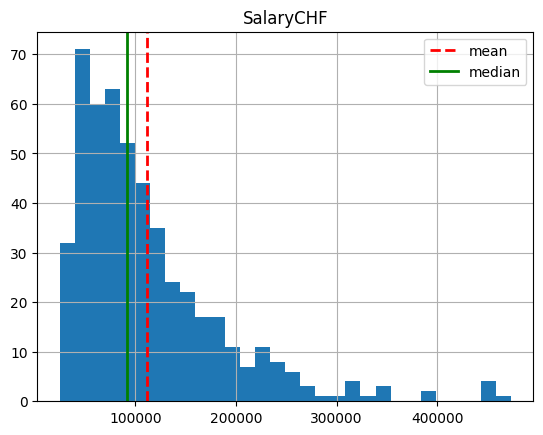

In [414]:
histo = data['SalaryCHF'].hist(bins=30)
mean = data['SalaryCHF'].mean()
median = data['SalaryCHF'].median()
histo.axvline(
    x=mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="mean"
)
histo.axvline(
    x=median,
    color="green",
    linestyle="-",
    linewidth=2,
    label="median"
)
plt.title('SalaryCHF')
plt.legend()
plt.show()

In [415]:
"""
from sklearn.compose import ColumnTransformer
print(data.isna().sum().sum()) # no more NaN value
print(data.dtypes)
print(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))
X = data.drop(columns=["SalaryCHF"])
#x = np.array(data['Canton']).reshape(-1, 1)
y = data["SalaryCHF"]
#y = np.array(data["Canton"]).reshape(-1,1)

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

print(cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression()),
])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
"""


'\nfrom sklearn.compose import ColumnTransformer\nprint(data.isna().sum().sum()) # no more NaN value\nprint(data.dtypes)\nprint(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))\nX = data.drop(columns=["SalaryCHF"])\n#x = np.array(data[\'Canton\']).reshape(-1, 1)\ny = data["SalaryCHF"]\n#y = np.array(data["Canton"]).reshape(-1,1)\n\ncat_cols = X.select_dtypes("object").columns.tolist()\nnum_cols = X.select_dtypes("number").columns.tolist()\n\nprint(cat_cols)\n\npreprocess = ColumnTransformer([\n    ("num", StandardScaler(), num_cols),\n    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])\n\nmodel = Pipeline([\n    ("prep", preprocess),\n    ("reg", LinearRegression()),\n])\n\nX_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)\nmodel.fit(X_train, y_train)\ny_pred = model.predict(X_test)\nscores = cross_val_score(model, X, y, cv=5, scoring="r2")\n'

In [416]:
counts = data["Canton"].value_counts()
rare = counts[counts < 10].index
print(f"{len(rare)} cCANTONS PUT TOGETHER, THEY ARE TOO RARE", list(rare))
data["Canton"] = data["Canton"].where(~data["Canton"].isin(rare), "Other")
data

12 cCANTONS PUT TOGETHER, THEY ARE TOO RARE ['SZ', 'NE', 'ZG', 'GR', 'SH', 'AR', 'NW', 'JU', 'OW', 'UR', 'AI', 'GL']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,ExpMin,ExpMax,ExpMid,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,7.0,20.0,13.5,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,4.0,10.0,7.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,2.0,6.0,4.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0.0,2.0,1.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,2.0,6.0,4.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,0.0,0.0,0.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,0.0,2.0,1.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,4.0,10.0,7.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,2.0,6.0,4.0,0,1,0,0,1,2,2


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
#print(data.isna().sum().sum()) # no more NaN value
#print(data.dtypes)
#print(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))
X = data.drop(columns=["SalaryCHF"])
#x = np.array(data['Canton']).reshape(-1, 1)
y = data["SalaryCHF"]
#y = np.array(data["Canton"]).reshape(-1,1)

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

#print(cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

ridge = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-3, 3, 25)),
    func=np.log,
    inverse_func=np.exp,
)

model = Pipeline([
    ("prep", preprocess),
    ("reg", ridge),
])


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=5, scoring="r2")



KFold(n_splits=5, random_state=42, shuffle=True)
[0.9922 0.9802 0.9901 0.9886 0.9747]
-0.06765726351587123


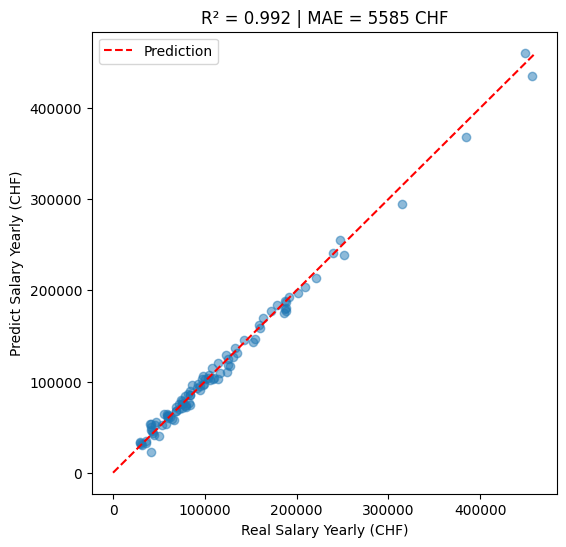

In [418]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = np.clip(y_pred, 0, None)  # Clamp negative predictions to zero

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(0,0), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Prediction")
plt.xlabel("Real Salary Yearly (CHF)")
plt.ylabel("Predict Salary Yearly (CHF)")
plt.title(f"R² = {r2_score(y_test, y_pred):.3f} | MAE = {mean_absolute_error(y_test, y_pred):.0f} CHF")
plt.legend()
plt.show()